# Semana 2 Clase 1

## De la simulación al ajuste: ¿cómo estimar parámetros con datos?

Pasaremos de simular con parámetros dados a usar datos para estimar parámetros.

## Problema 

Se midió la temperatura de una taza de café cada 5 minutos. La temperatura ambiente era aproximadamente $T_a = 25°C.$

Los datos observados fueron:

| $t$ | 0 | 5 | 10 | 15 | 20 | 25 | 30 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| $T_{\text{obs}}$ | 90 | 68 | 53 | 43 | 36 | 31 | 28 |

Queremos responder: ¿Qué valor de $k$ describe mejor el enfriamiento observado?



## Modelo matemático

Usaremos nuevamente el modelo discreto de enfriamiento:

$$T_{t+1} = T_t - k(T_t - T_a).$$

Pero ahora el objetivo no es solo simular, sino **ajustar** el valor de $k$.

En este modelo:

* $T_t =$ temperatura en el tiempo $t$,
* $T_a =$ temperatura ambiente,
* $k =$ constante de enfriamiento.

## Diferencia entre simulación y ajuste

### Simulación

En la simulación se eligen los parámetros:

$$T_0, \quad T_a, \quad k$$

y se generan valores futuros.

### Ajuste

En el ajuste se tienen datos observados y se busca el parámetro que reduce el error entre:

$$T_{\text{obs}}$$

y

$$T_{\text{modelo}}.$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
datos = {
    "tiempo": [0, 5, 10, 15, 20, 25, 30],
    "temperatura_observada": [90, 68, 53, 43, 36, 31, 28]
}

df_obs = pd.DataFrame(datos)

df_obs

,tiempo,temperatura_observada
0,0,90
1,5,68
2,10,53
3,15,43
4,20,36
5,25,31
6,30,28


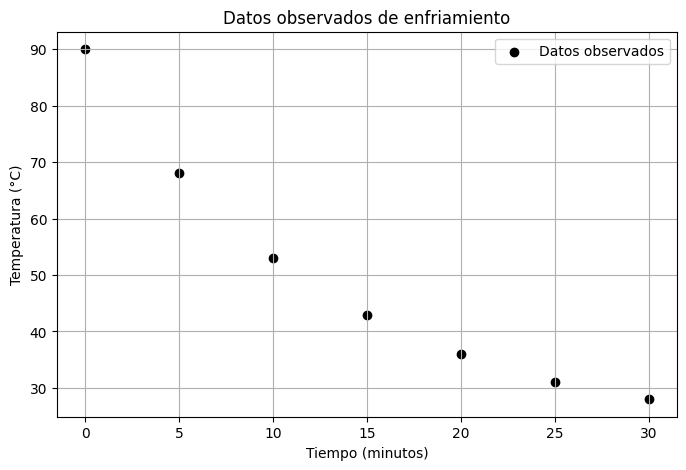

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_obs["tiempo"],
    df_obs["temperatura_observada"],
    label = "Datos observados",
    color = 'black'
)

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Datos observados de enfriamiento")
plt.legend()
plt.grid()

plt.show()

**Interpretación:** La temperatura disminuye rápidamente al inicio y después más lentamente. Este comportamiento es coherente con la ley de enfriamiento: cuando la diferencia con el ambiente es grande, el enfriamiento es más rápido.

Función para simular el modelo

In [4]:
def simular_enfriamiento(T0, Ta, k, tiempo_total):
    tiempos = np.arange(0, tiempo_total + 1)
    temperaturas = []

    T = T0

    for t in tiempos:
        temperaturas.append(T)
        T = T - k * (T - Ta)

    df_modelo = pd.DataFrame({
        "tiempo": tiempos,
        "temperatura_modelo": temperaturas
    })

    return df_modelo

In [5]:
T0 = 90
Ta = 25
k = 0.08 # Probamos primero con k=0.08
tiempo_total = 30

df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)

df_modelo.head()

,tiempo,temperatura_modelo
0,0,90.000000
1,1,84.800000
2,2,80.016000
3,3,75.614720
4,4,71.565542


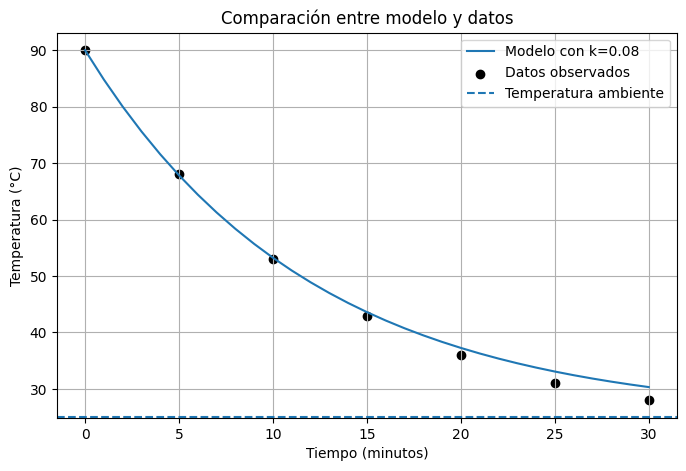

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo["tiempo"],
    df_modelo["temperatura_modelo"],
    label="Modelo con k=0.08"
)

plt.scatter(
    df_obs["tiempo"],
    df_obs["temperatura_observada"],
    label="Datos observados",
    color='black'
)

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación entre modelo y datos")
plt.legend()
plt.grid()

plt.show()

## Error del modelo

Para evaluar el ajuste usamos el error:

$$e_t = T_{\text{obs}}(t) - T_{\text{modelo}}(t).$$

Como los datos observados están cada 5 minutos, tomamos del modelo solamente esos tiempos.

In [7]:
df_comparacion = pd.merge(df_obs, df_modelo, on="tiempo")

df_comparacion["error"] = (
    df_comparacion["temperatura_observada"]
    - df_comparacion["temperatura_modelo"]
)

df_comparacion["error_absoluto"] = np.abs(df_comparacion["error"])
df_comparacion["error_cuadratico"] = df_comparacion["error"]**2

df_comparacion

,tiempo,temperatura_observada,temperatura_modelo,error,error_absoluto,error_cuadratico
0,0,90,90.000000,0.000000,0.000000,0.000000
1,5,68,67.840299,0.159701,0.159701,0.025504
2,10,53,53.235250,-0.235250,0.235250,0.055342
3,15,43,43.609331,-0.609331,0.609331,0.371285
4,20,36,37.265066,-1.265066,1.265066,1.600393
5,25,31,33.083679,-2.083679,2.083679,4.341717
6,30,28,30.327803,-2.327803,2.327803,5.418668


## Métricas de error

### Error absoluto medio (MAE)

Representa la diferencia promedio absoluta entre los valores observados y las predicciones del modelo.

* **Interpretación:** Es la métrica más intuitiva, ya que indica cuántos grados ($°C$), en promedio, se aleja el modelo de la realidad.
* **Características:** Trata todos los errores por igual, sin penalizar excesivamente las desviaciones grandes.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |e_i|$$

### Error cuadrático medio (MSE)

Es el promedio de los errores elevados al cuadrado.

* **Interpretación:** Al elevar al cuadrado, las unidades quedan expresadas en $°C^2$, lo que dificulta su interpretación directa.
* **Características:** Penaliza fuertemente los errores grandes. Es la métrica estándar para algoritmos de optimización debido a sus propiedades matemáticas (es una función suave y derivable).

$$MSE = \frac{1}{n} \sum_{i=1}^{n} e_i^2$$

### Raíz del error cuadrático medio (RMSE)

Es la raíz cuadrada del MSE, lo que permite devolver el error a las unidades originales del problema.

* **Interpretación:** Indica la magnitud del error en $°C$. Al ser más sensible a valores atípicos que el MAE, un RMSE significativamente mayor al MAE sugiere la presencia de errores puntuales importantes.
* **Uso:** Es la métrica más reportada en modelos de regresión y física.

$$RMSE = \sqrt{MSE}$$

In [8]:
mae = df_comparacion["error_absoluto"].mean()
mse = df_comparacion["error_cuadratico"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 0.9544042930510496
MSE: 1.6875584134223647
RMSE: 1.2990605888188451


### Interpretación de resultados

* **MAE (0.9544):** En promedio, las predicciones del modelo tienen un error de aproximadamente **0.95°C** respecto a la temperatura real. Es una medida lineal muy intuitiva del error.
* **MSE (1.6875):** Al elevar los errores al cuadrado, esta métrica penaliza más los errores grandes (si los hubiera). Es útil para funciones de optimización.
* **RMSE (1.2990):** Es la raíz del MSE y devuelve el error a las unidades originales (**°C**). Al ser mayor que el MAE, sugiere que existen algunas fluctuaciones o desviaciones ligeramente más grandes en ciertos puntos del tiempo que elevan el promedio cuadrático.

### ¿Qué nos dice esto?

Dado que la temperatura inicial era de **90°C** y bajó hasta los **28°C**, un error promedio de menos de **1.3°C** (RMSE) indica que el valor de $k$ que utilizamos describe con bastante precisión el fenómeno de enfriamiento físico de la taza.

Ahora probaremos muchos valores de $k$ y calculamos el error para cada uno.

In [9]:
valores_k = np.arange(0.01, 0.21, 0.01)

resultados = []

for k in valores_k:
    df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)

    df_comparacion = pd.merge(df_obs, df_modelo, on="tiempo")

    error = (
        df_comparacion["temperatura_observada"]
        - df_comparacion["temperatura_modelo"]
    )

    mae = np.mean(np.abs(error))
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)

    resultados.append({
        "k": k,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.01,31.329406,1219.126554,34.915993
1,0.02,24.135397,712.267990,26.688349
2,0.03,18.239579,402.272565,20.056734
3,0.04,13.386522,215.110144,14.666634
4,0.05,9.373003,105.024203,10.248132
5,0.06,6.037199,43.551837,6.599382
6,0.07,3.250112,12.859885,3.586068
7,0.08,0.954404,1.687558,1.299061
8,0.09,1.351841,2.865801,1.692868
9,0.10,2.749555,11.792805,3.434065


Elegimos el valor de $k$ que produce el menor RMSE.

In [10]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("Mejor valor encontrado:")
print(mejor)

Mejor valor encontrado:
k       0.080000
MAE     0.954404
MSE     1.687558
RMSE    1.299061
Name: 7, dtype: float64


In [18]:
k_mejor = mejor["k"]

print("k óptimo aproximado:", k_mejor)

k óptimo aproximado: 0.08


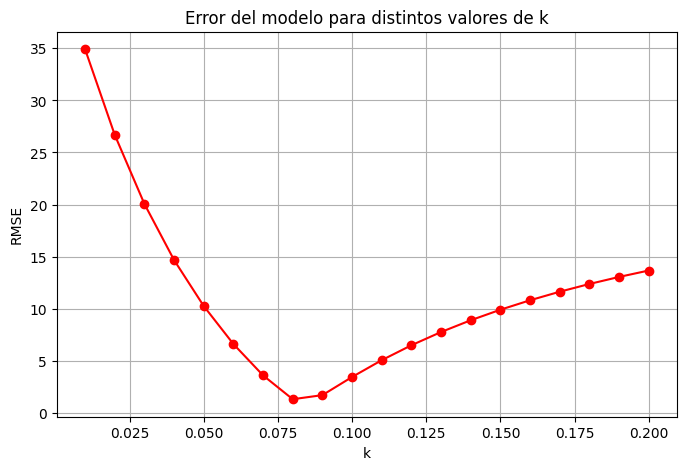

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(df_resultados["k"], df_resultados["RMSE"], 
         marker="o", color  = 'red')

plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error del modelo para distintos valores de k")
plt.grid()

plt.show()

El valor de k donde el RMSE es menor corresponde al parámetro que mejor ajusta el modelo a los datos observados, dentro de los valores probados.

Ahora simulamos nuevamente usando el mejor valor de k.

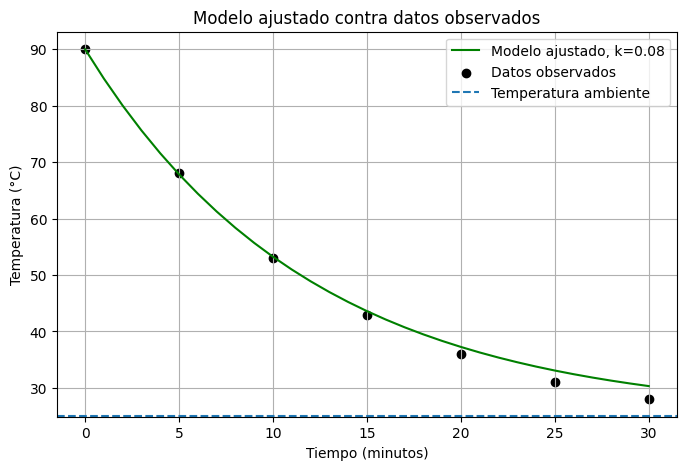

In [24]:
df_modelo_mejor = simular_enfriamiento(T0, Ta, k_mejor, tiempo_total)

plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo_mejor["tiempo"],
    df_modelo_mejor["temperatura_modelo"],
    label=f"Modelo ajustado, k={k_mejor:.2f}", color='green'
)

plt.scatter(
    df_obs["tiempo"],
    df_obs["temperatura_observada"],
    label="Datos observados", color='black'
)

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Modelo ajustado contra datos observados")
plt.legend()
plt.grid()

plt.show()

In [26]:
df_final = pd.merge(df_obs, df_modelo_mejor, on="tiempo")

df_final["error"] = (
    df_final["temperatura_observada"]
    - df_final["temperatura_modelo"]
)

df_final["error_absoluto"] = np.abs(df_final["error"])

df_final

,tiempo,temperatura_observada,temperatura_modelo,error,error_absoluto
0,0,90,90.000000,0.000000,0.000000
1,5,68,67.840299,0.159701,0.159701
2,10,53,53.235250,-0.235250,0.235250
3,15,43,43.609331,-0.609331,0.609331
4,20,36,37.265066,-1.265066,1.265066
5,25,31,33.083679,-2.083679,2.083679
6,30,28,30.327803,-2.327803,2.327803


El parámetro $k$ controla la rapidez del enfriamiento. Al comparar distintos valores de $k$, podemos elegir aquel que produce menor error respecto a los datos observados. Esto convierte al modelo en una herramienta más cercana a la realidad observada.

## Extensión: entrenamiento y prueba

1. **Datos de ajuste (Entrenamiento):** Usamos los primeros datos para calibrar el valor de $k$:

$$t = 0, 5, 10, 15$$


2. **Datos de evaluación (Prueba):** Usamos los datos restantes para validar qué tan bien predice el modelo valores que no "vio" durante el ajuste:

$$t = 20, 25, 30$$



Esta división sirve para verificar la **capacidad de generalización** del modelo. Un buen ajuste en los datos de entrenamiento no garantiza que el modelo sea útil; la verdadera prueba es ver si puede predecir correctamente el enfriamiento futuro en los datos de prueba.

In [12]:
df_obs["tiempo"] <= 15

0     True
1     True
2     True
3     True
4    False
5    False
6    False
Name: tiempo, dtype: bool

In [11]:
df_train = df_obs[df_obs["tiempo"] <= 15].copy()
df_test = df_obs[df_obs["tiempo"] > 15].copy()

print("Datos de entrenamiento")
print(df_train)

print("Datos de prueba")
print(df_test)

Datos de entrenamiento
   tiempo  temperatura_observada
0       0                     90
1       5                     68
2      10                     53
3      15                     43
Datos de prueba
   tiempo  temperatura_observada
4      20                     36
5      25                     31
6      30                     28


Ahora buscamos el mejor $k$ usando solo entrenamiento:

In [30]:
resultados_train = []

for k in valores_k:
    df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)
    df_comparacion = pd.merge(df_train, df_modelo, on="tiempo")

    error = (
        df_comparacion["temperatura_observada"]
        - df_comparacion["temperatura_modelo"]
    )

    rmse = np.sqrt(np.mean(error**2))

    resultados_train.append({
        "k": k,
        "RMSE_train": rmse
    })

df_resultados_train = pd.DataFrame(resultados_train)

mejor_train = df_resultados_train.loc[df_resultados_train["RMSE_train"]
                                      .idxmin()]
k_train = mejor_train["k"]

print("Mejor k usando entrenamiento:", k_train)

Mejor k usando entrenamiento: 0.08


Evaluamos en prueba:

In [31]:
df_modelo_train = simular_enfriamiento(T0, Ta, k_train, tiempo_total)

df_test_eval = pd.merge(df_test, df_modelo_train, on="tiempo")

error_test = (
    df_test_eval["temperatura_observada"]
    - df_test_eval["temperatura_modelo"]
)

rmse_test = np.sqrt(np.mean(error_test**2))

print(df_test_eval)
print("RMSE en prueba:", rmse_test)

   tiempo  temperatura_observada  temperatura_modelo
0      20                     36           37.265066
1      25                     31           33.083679
2      30                     28           30.327803
RMSE en prueba: 1.9460025315452851


El modelo ajustado con los primeros datos logra predecir razonablemente bien los datos posteriores, con un error típico cercano a 2∘C. Sin embargo, observamos que en todos los puntos de prueba el modelo predice temperaturas ligeramente mayores que las observadas. Esto sugiere que el modelo está enfriando un poco más lento que el fenómeno observado.

### Interpretación del error en prueba

El modelo fue ajustado usando únicamente los primeros datos y después se evaluó en los tiempos \(t=20,25,30\). El valor obtenido fue

$$
RMSE_{\text{prueba}} = 1.9460.
$$

Esto significa que, en los datos de prueba, el modelo presenta un error típico de aproximadamente $1.95^\circ C$. 

Además, se observa que en los tres puntos de prueba la temperatura predicha por el modelo es mayor que la temperatura observada. Por lo tanto, el modelo está sobreestimando ligeramente la temperatura del café, es decir, predice un enfriamiento un poco más lento que el observado.

Aun así, el error es pequeño en relación con el rango total de temperaturas observado, por lo que el modelo puede considerarse una primera aproximación razonable al proceso de enfriamiento.

**Un buen modelo no solo ajusta datos conocidos, también debe predecir razonablemente datos nuevos.**

## Tarea. Modelo de saturación para crecimiento de usuarios


Una aplicación móvil nueva comienza a ganar usuarios durante sus primeras semanas. Al inicio el crecimiento es rápido, pero conforme pasa el tiempo, el número de usuarios se acerca a un límite máximo debido a que el mercado disponible no es infinito.

Para modelar este comportamiento se propone el siguiente **modelo de saturación**:

$$
U(t)=L\left(1-e^{-kt}\right)
$$

donde:

* $U(t)$ es el número de usuarios acumulados en la semana (t),
* $L$ es el número máximo esperado de usuarios,
* $k$ es el parámetro de crecimiento,
* $t$ es el tiempo medido en semanas.

Supongamos que, por estudios previos, se estima que el máximo esperado es $L=10000$.

Por lo tanto, el modelo queda como:

$$
U(t)=10000\left(1-e^{-kt}\right)
$$



#### Datos observados

Se registró el número acumulado de usuarios durante 12 semanas:

| Semana | Usuarios observados |
| -----: | ------------------: |
|      1 |                 950 |
|      2 |                1800 |
|      3 |                2650 |
|      4 |                3400 |
|      5 |                4100 |
|      6 |                4800 |
|      7 |                5400 |
|      8 |                5900 |
|      9 |                6350 |
|     10 |                6750 |
|     11 |                7100 |
|     12 |                7400 |



# Actividades

## Parte 1. Probar el modelo con un parámetro dado

Usa inicialmente $k=0.10$

1. Define una función en Python para el modelo:

$$
U(t)=10000\left(1-e^{-kt}\right)
$$

2. Calcula los valores estimados por el modelo para las semanas $1,2,\ldots,12$.

3. Construye un `DataFrame` con las columnas:

```python
semana
usuarios_observados
usuarios_modelo
```

4. Grafica en una misma figura:

* los usuarios observados,
* los usuarios estimados por el modelo.

5. Interpreta visualmente si el modelo con (k=0.10) se ajusta bien a los datos.



## Parte 2. Métricas de error

Calcula las siguientes métricas de error:

### Error absoluto medio

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

### Error cuadrático medio

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Raíz del error cuadrático medio

$$
RMSE=\sqrt{MSE}
$$

donde:

* $y_i$ representa los datos observados,
* $\hat{y}_i$ representa los valores estimados por el modelo.

Responde:

1. ¿Cuál es el MAE del modelo?
2. ¿Cuál es el MSE?
3. ¿Cuál es el RMSE?
4. ¿El error es grande o pequeño en comparación con el número de usuarios?


## Parte 3. Ajuste del parámetro $k$

Ahora prueba varios valores posibles para (k):

$$
k \in \{0.05, 0.06, 0.07, \ldots, 0.20\}
$$

1. Para cada valor de (k), calcula los valores estimados por el modelo.
2. Calcula el MAE, MSE y RMSE.
3. Guarda los resultados en un `DataFrame` con columnas:

```python
k
MAE
MSE
RMSE
```

4. Encuentra el valor de $k$ que produce el menor RMSE.
5. Grafica el RMSE contra $k$.

Responde:

1. ¿Cuál es el mejor valor de $k$?
2. ¿Cuál fue el menor RMSE obtenido?
3. ¿Qué significa que un valor de (k) tenga menor RMSE que otro?
4. ¿El modelo mejora respecto al caso inicial $k=0.10$?


## Parte 4. Modelo con el mejor parámetro

Usando el mejor valor de $k$ encontrado:

1. Calcula nuevamente los valores estimados por el modelo.
2. Grafica los datos observados y el modelo ajustado.
3. Compara visualmente el modelo inicial con $k=0.10$ y el modelo ajustado.

Responde:

1. ¿El modelo ajustado sigue mejor la tendencia de los datos?
2. ¿En qué semanas se observa mayor diferencia entre los datos y el modelo?
3. ¿Crees que el modelo es razonable para describir el crecimiento de usuarios?



# Extensión. Entrenamiento y prueba

Ahora se quiere evaluar si el parámetro encontrado realmente funciona bien para datos no usados durante el ajuste.

Divide los datos en dos partes:

### Datos de entrenamiento

Semanas 1 a 8.

### Datos de prueba

Semanas 9 a 12.


## Actividades de la extensión

1. Usa solamente las semanas 1 a 8 para buscar el mejor valor de (k).
2. Prueba nuevamente valores:

$
k \in \{0.05, 0.06, 0.07, \ldots, 0.20\}
$

3. Para cada valor de $k$, calcula el RMSE usando solo los datos de entrenamiento.
4. Encuentra el mejor parámetro $k_{\text{mejor}}$.
5. Usa ese valor de $k_{\text{mejor}}$ para predecir los usuarios en las semanas 9 a 12.
6. Calcula las métricas MAE, MSE y RMSE en el conjunto de prueba.
7. Grafica:

* datos observados de entrenamiento,
* datos observados de prueba,
* modelo ajustado.



## Preguntas finales

1. ¿Cuál fue el mejor valor de (k) usando solamente los datos de entrenamiento?
2. ¿Cuál fue el RMSE en entrenamiento?
3. ¿Cuál fue el RMSE en prueba?
4. ¿El modelo generaliza bien a las semanas que no se usaron para ajustar el parámetro?
5. ¿Qué diferencia hay entre ajustar el parámetro usando todos los datos y ajustarlo usando solo entrenamiento?
6. ¿Por qué es importante separar datos de entrenamiento y prueba?
